# PE7 mouse multiplexed editing coverage

**Kexin Dong**

Createed: Apr 27, 2026;

Last updated: June 2, 2026

This notebook quantifies cancer-associated mutation combinations amenable to modeling by PE7 multiplexed prime editing.

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
from pegg import prime
import bioh2m as h2m
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from scipy.stats import combine_pvalues

yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

In [60]:
purple_muted = '#8E8AB8'   # parental / wild-type
green_muted  = '#7FA77F'   # variant family
blue_pair    = '#5A8DC8'   # single / category A
gold_pair    = '#E8B85F'   # combination / category B
red_ctrl     = '#C86A6A'   # negative controls
gray_bg      = '#C8C8C8'   # background scatter

# sequential blues (panel i)
blues_5 = sns.color_palette('Blues', 6)[1:]   # skip lightest
# sequential greens (panel j)
greens_5 = sns.color_palette('Greens', 6)[1:]

# diverging (panel e)
diverging = sns.diverging_palette(230, 20, s=60, l=70, as_cmap=True)

## Overview and Rationale

Aim: Show that PE7 multiplexed prime editing expands the spectrum of cancer driver mutation combinations that can be modeled in mice.


- Use AACR-GENIE as the patient cohort (pan-cancer, reasonably sized — PEGG guide generation is slow so we avoid going huge).
    - Compute VAF per mutation as t_alt_count / (t_alt_count + t_ref_count); drop rows without VAF info.
    - Map top-VAF human mutations to mouse alleles via H2M Database v1.
    - Run PEGG on these mouse alleles to determine which can be modeled with PE.

## Data Sources
- AACR-GENIE
- MMRRC: https://www.mmrrc.org/
- PEGG pipeline: https://www.nature.com/articles/s41587-024-02172-9
- H2M: https://www.nature.com/articles/s41587-025-02925-0

In [61]:
# use v15 to stay consistent with H2M Database
df_mutation_aacr = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v15.0/data_mutations_extended.txt',
                          header=0, sep='\t', comment="#", 
                          na_values=['Not Applicable', 'NA', 'NULL', '-', 'None', ''])
df_pts = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v15.0/data_clinical_patient.txt', header=0, sep='\t', comment="#", na_values = ['Not Applicable', 'NA', 'NULL', '-', 'None', ''])
df_sample = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v15.0/data_clinical_sample.txt', header=0, sep='\t', comment="#", na_values = ['Not Applicable', 'NA', 'NULL', '-', 'None', ''])

In [62]:
# TODO:
# calculate VAF and insert after 'Tumor_Seq_Allele2', and drop rows with missing VAF
df_mutation_aacr['VAF'] = df_mutation_aacr['t_alt_count'] / (df_mutation_aacr['t_alt_count'] + df_mutation_aacr['t_ref_count'])
insert_idx = df_mutation_aacr.columns.get_loc('Tumor_Seq_Allele2') + 1
df_mutation_aacr.insert(insert_idx, 'VAF', df_mutation_aacr.pop('VAF'))

n_before = len(df_mutation_aacr)
df_mutation_aacr = df_mutation_aacr[df_mutation_aacr['VAF'].notna()].reset_index(drop=True)
n_after = len(df_mutation_aacr)

print(f'Mutations: {n_before:,} -> {n_after:,} ({n_after/n_before*100:.1f}% kept)')
print(f'Unique patients with VAF info: {df_mutation_aacr["Tumor_Sample_Barcode"].nunique():,}')

Mutations: 1,840,311 -> 1,381,528 (75.1% kept)
Unique patients with VAF info: 131,529


In [63]:
# TODO:
# keep at most three mutations for each sample, and keep the one with highest VAF if there are multiple mutations for the same sample
df_mutation_aacr = df_mutation_aacr.sort_values(['Tumor_Sample_Barcode', 'VAF'], ascending=[True, False]).groupby('Tumor_Sample_Barcode').head(3).reset_index(drop=True)

In [64]:
df_mutation_aacr.columns

Index(['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome',
       'Start_Position', 'End_Position', 'Strand', 'Consequence',
       'Variant_Classification', 'Variant_Type', 'Reference_Allele',
       'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'VAF', 'dbSNP_RS',
       'dbSNP_Val_Status', 'Tumor_Sample_Barcode',
       'Matched_Norm_Sample_Barcode', 'Match_Norm_Seq_Allele1',
       'Match_Norm_Seq_Allele2', 'Tumor_Validation_Allele1',
       'Tumor_Validation_Allele2', 'Match_Norm_Validation_Allele1',
       'Match_Norm_Validation_Allele2', 'Verification_Status',
       'Validation_Status', 'Mutation_Status', 'Sequencing_Phase',
       'Sequence_Source', 'Validation_Method', 'Score', 'BAM_File',
       'Sequencer', 't_ref_count', 't_alt_count', 'n_ref_count', 'n_alt_count',
       'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'RefSeq',
       'Protein_position', 'Codons', 'Exon_Number', 'gnomAD_AF',
       'gnomAD_AFR_AF', 'gnomAD_AMR_AF', 'gnomAD_ASJ_AF', 'gnomAD

In [65]:
df_mutation_aacr['Hugo_Symbol'].value_counts().head(20)

Hugo_Symbol
TP53      42901
KRAS      13673
PIK3CA     8124
APC        6745
EGFR       5344
PTEN       4870
TERT       4774
BRAF       4311
ARID1A     3508
KMT2D      3381
TET2       3251
RB1        3126
ATM        2897
DNMT3A     2676
SMAD4      2625
NF1        2454
NRAS       2452
NOTCH1     2323
ATRX       2290
KMT2C      2264
Name: count, dtype: int64

In [66]:
# TODO:Then generate a df_mut_top3_undup with only the top 3 mutations for each sample, and no duplicated samples
# the way of doing this is to only keep Hugo_Symbol, 'Chromosome','Start_Position', 'End_Position', 'Strand', 'Consequence', 'Variant_Classification', 'Variant_Type', 'Reference_Allele','Tumor_Seq_Allele1', 'Tumor_Seq_Allele2'

keep_cols = ['Hugo_Symbol', 'Chromosome', 'Start_Position', 'End_Position',
             'Strand', 'Consequence', 'Variant_Classification', 'Variant_Type',
             'Reference_Allele', 'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2']

df_mut_top3_undup = (
    df_mutation_aacr
    [keep_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f'Unique top-3 mutations: {len(df_mut_top3_undup):,}')
df_mut_top3_undup.head()


Unique top-3 mutations: 174,056


,Hugo_Symbol,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2
0,INPP4B,4,143066998,143066998,+,missense_variant,Missense_Mutation,SNP,G,G,C
1,ARID2,12,46244872,46244872,+,missense_variant,Missense_Mutation,SNP,C,C,T
2,ARAF,X,47424707,47424707,+,missense_variant,Missense_Mutation,SNP,C,C,T
3,FLT3,13,28608256,28608258,+,inframe_deletion,In_Frame_Del,DEL,ATC,ATC,NaN
4,CDKN2A,9,21971120,21971120,+,stop_gained,Nonsense_Mutation,SNP,G,G,A


In [67]:
# TODO: load H2M modeling results and fuse it to df_mut_top3_undup to generate df_mut_top3_undup_h2m_fused

# then plot a bar plot to show two bars of single, dual, and triple H2M coverage at a patient level, and show the percentage of each bar on top of the bar.

# all bar: gray
# H2M bar: color of blue_pair

db_h2m = pd.read_csv('/Users/kexindong/Documents/GitHub/Output/h2m_database/database-output-final/df_result_cleaned_v3.csv')

In [68]:
db_h2m.columns

Index(['gene_name_h', 'gene_id_h', 'tx_id_h', 'chr_h', 'exon_num_h',
       'strand_h', 'match', 'start_h', 'end_h', 'ref_seq_h', 'alt_seq_h',
       'HGVSc_h', 'HGVSp_h', 'classification_h', 'exon_h', 'type_h', 'status',
       'class', 'statement', 'flank_size_left', 'flank_size_right',
       'gene_name_m', 'gene_id_m', 'tx_id_m', 'chr_m', 'exon_num_m',
       'strand_m', 'type_m', 'classification_m', 'exon_m', 'start_m_ori',
       'end_m_ori', 'ref_seq_m_ori', 'alt_seq_m_ori', 'HGVSc_m_ori',
       'HGVSp_m_ori', 'start_m', 'end_m', 'ref_seq_m', 'alt_seq_m', 'HGVSc_m',
       'HGVSp_m', 'ID_human', 'ID_mouse', 'Database', 'ID_db', 'pe_human',
       'pe_mouse', 'be_human', 'be_mouse', 'expanded', 'flank_size'],
      dtype='object')

In [69]:
# --- Symbol harmonization ---
dict_of_aacr_symbol = {
    'H3F3A':'H3-3A','H3F3B':'H3-3B','WHSC1':'NSD1','GPR124':'ADGRA2','MKL1':'MRTFA',
    'PARK2':'PRKN','MRE11A':'MRE11','MLLT4':'AFDN','CASC5':'KNL1','MEF2BNB-MEF2B':'BORCS8-MEF2B',
    'PAK7':'PAK5','HIST1H1C':'H1-2','HIST1H3B':'H3C1','HIST1H1E':'H1-4','HIST1H2BD':'H2BC5',
    'HIST3H3':'H3-4','HIST1H3D':'H3C2','HIST1H3E':'H3C3','HIST1H3J':'H3C12','HIST1H2BK':'H2BC8',
    'HIST1H3F':'H3C4','HIST1H1B':'H1-5','HIST1H1D':'H1-3','HIST1H2AC':'H2AC1','HIST1H2BJ':'H2BC13',
    'HIST1H4E':'H4C5','FAM46C':'TENT5C','WHSC1L1':'NSD3','SETD8':'KMT5A','LPHN3':'ADGRL3',
    'BAI3':'ADGRB3','SEPT9':'NAPB','BRE':'BABAM2','RFWD2':'COP1','TCEB1':'ELOC','GBA':'GBA1',
    'PVRL4':'NECTIN4','ICK':'GCKR','GNB2L1':'RACK1','MGEA5':'OGA','DIRC2':'SLC49A4',
    'LARGE':'LARGE1','TMEM173B':'STING1','SEPT5':'SEPTIN5'
}
df_mut_top3_undup['Hugo_Symbol'] = df_mut_top3_undup['Hugo_Symbol'].replace(dict_of_aacr_symbol)

In [70]:
# --- Build H2M lookup: one row per unique human mutation ---
h2m_lookup = db_h2m[db_h2m['Database'] == 'AACR'].reset_index(drop=True)

h2m_lookup = (
    h2m_lookup[['gene_name_h', 'chr_h', 'start_h', 'end_h', 'ref_seq_h', 'alt_seq_h', 'status','ID_human','ID_mouse','type_h']]
    .copy()
)
h2m_lookup['chr_h'] = h2m_lookup['chr_h'].str.replace('^chr', '', regex=True)


h2m_lookup = h2m_lookup.rename(columns={
    'gene_name_h': 'Hugo_Symbol', 'chr_h': 'Chromosome',
    'start_h': 'Start_Position', 'end_h': 'End_Position',
    'ref_seq_h': 'Reference_Allele', 'alt_seq_h': 'Tumor_Seq_Allele2',
    'status': 'h2m_status',
    'type_h': 'Variant_Type',
})

# align dtypes for join
df_mut_top3_undup['Chromosome'] = df_mut_top3_undup['Chromosome'].astype(str)
h2m_lookup['Chromosome'] = h2m_lookup['Chromosome'].astype(str)

In [71]:
# Patch indel encoding in df_mut_top3_undup before merge
df_mut_top3_undup['Reference_Allele'] = df_mut_top3_undup['Reference_Allele'].fillna('-')
df_mut_top3_undup['Tumor_Seq_Allele2'] = df_mut_top3_undup['Tumor_Seq_Allele2'].fillna('-')

# Same for df_mutation_aacr if you use it again downstream
df_mutation_aacr['Reference_Allele'] = df_mutation_aacr['Reference_Allele'].fillna('-')
df_mutation_aacr['Tumor_Seq_Allele2'] = df_mutation_aacr['Tumor_Seq_Allele2'].fillna('-')

In [72]:
df_mut_top3_undup_h2m_fused = df_mut_top3_undup.merge(
    h2m_lookup,
    on=['Hugo_Symbol', 'Chromosome', 'Start_Position', 'End_Position',
        'Reference_Allele', 'Tumor_Seq_Allele2','Variant_Type'],
    how='left'
)

In [73]:
df_mut_top3_undup_h2m_fused['h2m_modelable'] = df_mut_top3_undup_h2m_fused['h2m_status'] == True

n_total = len(df_mut_top3_undup_h2m_fused)
n_modelable = df_mut_top3_undup_h2m_fused['h2m_modelable'].sum()
n_class4 = ((df_mut_top3_undup_h2m_fused['h2m_status'] == False)).sum()
n_no_homolog = df_mut_top3_undup_h2m_fused['h2m_status'].isna().sum()

print(f'Unique mutations appearing in any sample\'s top-3: {n_total:,}')
print(f'  H2M-modelable (status=True):          {n_modelable:,} ({n_modelable/n_total*100:.1f}%)')
print(f'  In H2M but not modelable (status=False): {n_class4:,} ({n_class4/n_total*100:.1f}%)')
print(f'  No mouse homolog (not in H2M):        {n_no_homolog:,} ({n_no_homolog/n_total*100:.1f}%)')

Unique mutations appearing in any sample's top-3: 197,219
  H2M-modelable (status=True):          159,329 (80.8%)
  In H2M but not modelable (status=False): 28,151 (14.3%)
  No mouse homolog (not in H2M):        9,739 (4.9%)


Top-1: 128,516/131,529 patients fully H2M-modelable (97.7%)
Top-2: 100,925/112,425 patients fully H2M-modelable (89.8%)
Top-3: 60,442/96,170 patients fully H2M-modelable (62.8%)


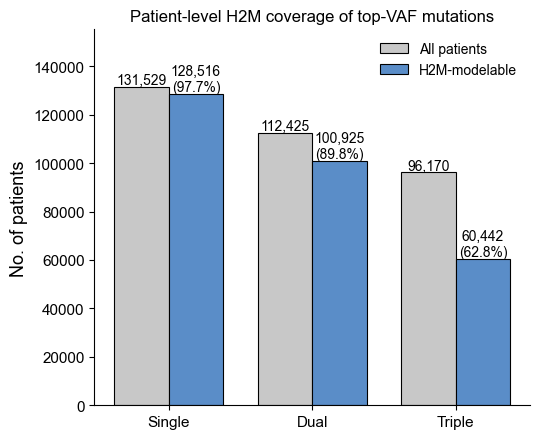

In [74]:
# --- Per-sample top-3 (keep sample info) ---
df_top3_per_sample = (
    df_mutation_aacr
    .sort_values('VAF', ascending=False)
    .groupby('Tumor_Sample_Barcode', sort=False)
    .head(3)
    .copy()
)
df_top3_per_sample['Hugo_Symbol'] = df_top3_per_sample['Hugo_Symbol'].replace(dict_of_aacr_symbol)
df_top3_per_sample['Chromosome'] = df_top3_per_sample['Chromosome'].astype(str)

# Merge H2M status
df_top3_per_sample = df_top3_per_sample.merge(
    h2m_lookup,
    on=['Hugo_Symbol', 'Chromosome', 'Start_Position', 'End_Position',
        'Reference_Allele', 'Tumor_Seq_Allele2'],
    how='left'
)
df_top3_per_sample['h2m_modelable'] = df_top3_per_sample['h2m_status'] == True

# Rank within sample by VAF (1 = highest)
df_top3_per_sample['vaf_rank'] = (
    df_top3_per_sample.groupby('Tumor_Sample_Barcode')['VAF']
    .rank(ascending=False, method='first').astype(int)
)

# --- Patient-level coverage: top-N all modelable ---
# Denominator: patients with at least N mutations (with VAF) — only these can have a "top-N"
counts_per_sample = df_top3_per_sample.groupby('Tumor_Sample_Barcode').size()
modelable_per_sample = df_top3_per_sample.groupby('Tumor_Sample_Barcode')['h2m_modelable'].sum()

results = {}
for n in [1, 2, 3]:
    eligible = counts_per_sample[counts_per_sample >= n].index
    n_total = len(eligible)
    n_covered = (modelable_per_sample.loc[eligible] >= n).sum()
    results[n] = (n_total, n_covered)
    print(f'Top-{n}: {n_covered:,}/{n_total:,} patients fully H2M-modelable ({n_covered/n_total*100:.1f}%)')

# --- Bar plot ---
labels = ['Single', 'Dual', 'Triple']
totals = [results[n][0] for n in [1, 2, 3]]
covered = [results[n][1] for n in [1, 2, 3]]
pcts = [c/t*100 for c, t in zip(covered, totals)]

blue_pair = '#5A8DC8'
gray = '#C8C8C8'

fig, ax = plt.subplots(figsize=(5.5, 4.5))
x = np.arange(len(labels))
w = 0.38
b1 = ax.bar(x - w/2, totals, w, color=gray, edgecolor='black', linewidth=0.8, label='All patients')
b2 = ax.bar(x + w/2, covered, w, color=blue_pair, edgecolor='black', linewidth=0.8, label='H2M-modelable')

for bar, val in zip(b1, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:,}',
            ha='center', va='bottom', fontsize=10)
for bar, val, pct in zip(b2, covered, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=13)
ax.set_ylabel('No. of patients', fontsize=13)
ax.set_title('Patient-level H2M coverage of top-VAF mutations', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.set_ylim(0, max(totals) * 1.18)
fig.tight_layout()
# plt.savefig('figures/h2m_patient_coverage.pdf', bbox_inches='tight')
plt.show()


## Full cohort coverage (all AACR-GENIE centers)

Same logic as the YALE subset, but applied across the full ~131K patients.
`PE7-amenable (NGG PAM)` uses `data/pegRNAs_full_filtered.csv` — the full-cohort PEGG run.
The NG PAM bar is only available for YALE (we did not rerun PEGG on the full cohort with NG).

In [75]:
# Load full-cohort pegRNAs (NGG PAM, already filtered) and tag PE7 amenability
pegRNAs_full = pd.read_csv('data/pegRNAs_full_filtered.csv')
print(f'Full pegRNAs (NGG, filtered): {len(pegRNAs_full):,}')
print(f'Unique mouse variants with at least one NGG pegRNA: {pegRNAs_full["ID_mouse"].nunique():,}')

ngg_amenable_id_mouse = set(pegRNAs_full['ID_mouse'].unique())
df_top3_per_sample['pe7_amenable_ngg'] = (
    (df_top3_per_sample['h2m_modelable']) &
    (df_top3_per_sample['ID_mouse'].isin(ngg_amenable_id_mouse))
)


Full pegRNAs (NGG, filtered): 275,558
Unique mouse variants with at least one NGG pegRNA: 111,057


Top-1: total 131,529 | H2M 111,035 (84.4%) | PE7-NGG 89,921 (68.4%)
Top-2: total 112,425 | H2M 79,968 (71.1%) | PE7-NGG 47,808 (42.5%)
Top-3: total 96,170 | H2M 57,505 (59.8%) | PE7-NGG 24,543 (25.5%)


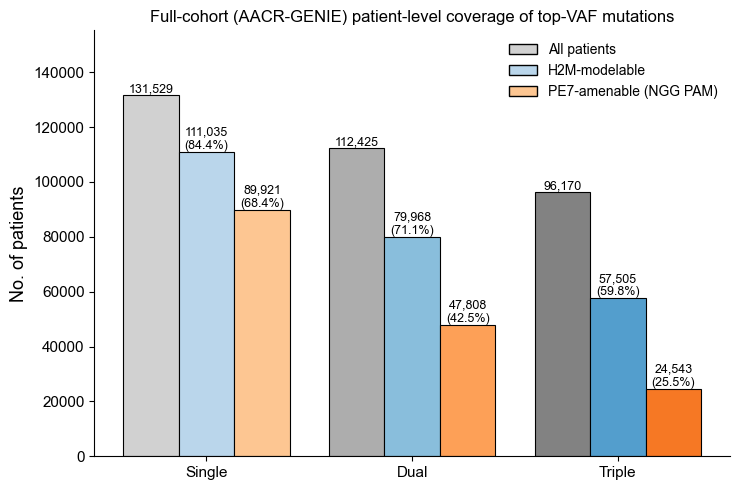

In [76]:
# --- Full-cohort patient-level coverage (NGG PAM only) ---
# Strict semantics: "Top-N covered" means top-1..N (by VAF rank) are ALL amenable.

def strict_topn_covered(df, flag_col):
    """Per patient, check whether top-1..N (by vaf_rank) are all True in flag_col.
       Returns dict {n: (n_total_eligible, n_covered)}."""
    pv = df.pivot_table(index='Tumor_Sample_Barcode', columns='vaf_rank',
                        values=flag_col, aggfunc='first')
    out = {}
    for n in [1, 2, 3]:
        elig = pv.dropna(subset=list(range(1, n+1)))      # patients with >=n top muts
        covered = elig[list(range(1, n+1))].all(axis=1)
        out[n] = (len(elig), int(covered.sum()))
    return out

h2m_res = strict_topn_covered(df_top3_per_sample, 'h2m_modelable')
ngg_res = strict_topn_covered(df_top3_per_sample, 'pe7_amenable_ngg')

results_full = {}
for n in [1, 2, 3]:
    n_total, n_h2m = h2m_res[n]
    _,       n_ngg = ngg_res[n]
    results_full[n] = (n_total, n_h2m, n_ngg)
    print(f'Top-{n}: total {n_total:,} | H2M {n_h2m:,} ({n_h2m/n_total*100:.1f}%) '
          f'| PE7-NGG {n_ngg:,} ({n_ngg/n_total*100:.1f}%)')

# --- 3-bar plot (full cohort, NGG only) ---
labels = ['Single', 'Dual', 'Triple']
totals  = [results_full[n][0] for n in [1, 2, 3]]
h2m_cov = [results_full[n][1] for n in [1, 2, 3]]
ngg_cov = [results_full[n][2] for n in [1, 2, 3]]
h2m_pct = [c/t*100 for c, t in zip(h2m_cov, totals)]
ngg_pct = [c/t*100 for c, t in zip(ngg_cov, totals)]

grays_3   = sns.color_palette('Greys',   6)[1:4]
blues_3   = sns.color_palette('Blues',   6)[1:4]
oranges_3 = sns.color_palette('Oranges', 6)[1:4]

fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(len(labels))
w = 0.27

for i in range(3):
    ax.bar(x[i] - w, totals[i],  w, color=grays_3[i],   edgecolor='black', linewidth=0.8)
    ax.bar(x[i],     h2m_cov[i], w, color=blues_3[i],   edgecolor='black', linewidth=0.8)
    ax.bar(x[i] + w, ngg_cov[i], w, color=oranges_3[i], edgecolor='black', linewidth=0.8)

for i in range(3):
    ax.text(x[i] - w, totals[i],  f'{totals[i]:,}',
            ha='center', va='bottom', fontsize=9)
    ax.text(x[i],     h2m_cov[i], f'{h2m_cov[i]:,}\n({h2m_pct[i]:.1f}%)',
            ha='center', va='bottom', fontsize=9)
    ax.text(x[i] + w, ngg_cov[i], f'{ngg_cov[i]:,}\n({ngg_pct[i]:.1f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylabel('No. of patients', fontsize=13)
ax.set_title('Full-cohort (AACR-GENIE) patient-level coverage of top-VAF mutations', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(totals) * 1.18)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=grays_3[0],   edgecolor='black', label='All patients'),
    Patch(facecolor=blues_3[0],   edgecolor='black', label='H2M-modelable'),
    Patch(facecolor=oranges_3[0], edgecolor='black', label='PE7-amenable (NGG PAM)'),
]
ax.legend(handles=legend_elems, frameon=False, fontsize=10, loc='upper right')

fig.tight_layout()
# plt.savefig('figures/full_patient_coverage.pdf', bbox_inches='tight')
plt.show()


In [77]:
# --- GEMM coverage: which top-VAF mutations can be modeled by ANY breeding of existing mouse models ---
# Source: data/GEMM_cancer_alleles_clean.xlsx (909 alleles, from MMHCdb + MGI)
# TSG list: COSMIC Cancer Gene Census (any role containing "TSG")

gemm = pd.read_excel('data/GEMM_cancer_alleles_clean.xlsx')

cosmic = pd.read_csv('data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
tsg_roles = {'TSG', 'TSG, fusion', 'oncogene, TSG', 'oncogene, TSG, fusion'}
tsg_genes = set(cosmic.loc[cosmic['Role in Cancer'].isin(tsg_roles), 'Gene Symbol'])
print(f'COSMIC TSGs: {len(tsg_genes):,}')

COSMIC TSGs: 321


In [78]:
# (1) Point-mutation-level set: gene + specific amino-acid change
point_cats = {'Point mutation / knock-in', 'Humanized', 'Spontaneous / chemically induced'}
gemm_point = gemm[gemm['Allele Category'].isin(point_cats)].copy()

In [79]:
def parse_human_allele(s):
    # "KRAS G12D"           -> [("KRAS", "p.G12D")]
    # "FGFR3 K644M/K650M"   -> [("FGFR3", "p.K644M"), ("FGFR3", "p.K650M")]
    # Skip LoF / engineered placeholders
    if not isinstance(s, str):
        return []
    parts = s.strip().split(None, 1)
    if len(parts) != 2:
        return []
    gene, mut = parts[0], parts[1].strip()
    if 'loss-of-function' in mut.lower() or mut.lower() in {'(engineered allele)', '(spontaneous)'}:
        return []

    # Split slash-separated equivalents (mouse/human residue notations)
    results = []
    for m in mut.split('/'):
        m = m.strip()
        if not m:
            continue
        if not m.startswith('p.'):
            m = 'p.' + m
        results.append((gene, m))
    return results

gemm_point_set = set()
for s in gemm_point['Human Mutant Allele']:
    gemm_point_set.update(parse_human_allele(s))
print(f'Point-mutation GEMM alleles (gene + HGVSp): {len(gemm_point_set):,}')


Point-mutation GEMM alleles (gene + HGVSp): 83


In [80]:
# (2) Gene-level set: any KO / Conditional GEMM exists for this gene
ko_cond_cats = {'Knockout / null', 'Conditional'}
gemm_ko_genes = set(gemm.loc[gemm['Allele Category'].isin(ko_cond_cats),
                             'Corresponding Human Gene'].dropna())
print(f'Genes with KO/Conditional GEMM: {len(gemm_ko_genes):,}')


Genes with KO/Conditional GEMM: 691


In [81]:
df_top3_per_sample['Variant_Classification'].value_counts()

Variant_Classification
Missense_Mutation         246879
Nonsense_Mutation          44775
Frame_Shift_Del            27601
Frame_Shift_Ins            12737
Splice_Site                12009
Silent                     11112
In_Frame_Del                7764
5'Flank                     5747
Intron                      4548
Splice_Region               2899
In_Frame_Ins                2585
3'Flank                      954
5'UTR                        597
Translation_Start_Site       502
3'UTR                        371
Nonstop_Mutation             226
RNA                          161
Name: count, dtype: int64

In [82]:
# Tag df_top3_per_sample
lof_classes = {'Nonsense_Mutation', 'Frame_Shift_Ins', 'Frame_Shift_Del',
               'Splice_Site', 'Splice_Region', 'Nonstop_Mutation', 'Translation_Start_Site'}

def is_gemm_amenable(row):
    gene = row['Hugo_Symbol']
    hgvsp = row.get('HGVSp_Short')
    if isinstance(hgvsp, str) and (gene, hgvsp) in gemm_point_set:
        return True
    if gene in gemm_ko_genes:
        if row.get('Variant_Classification') in lof_classes:
            return True
        if gene in tsg_genes:
            return True
    return False

df_top3_per_sample['gemm_amenable'] = df_top3_per_sample.apply(is_gemm_amenable, axis=1)

n_muts = len(df_top3_per_sample)
n_gemm = df_top3_per_sample['gemm_amenable'].sum()
print(f'\nTop-3 mutation rows: {n_muts:,}')
print(f'  GEMM-amenable:     {n_gemm:,} ({n_gemm/n_muts*100:.1f}%)')


Top-3 mutation rows: 381,467
  GEMM-amenable:     158,495 (41.5%)


Top-1: total 131,529 | H2M 111,035 (84.4%) | GEMM 63,193 (48.0%) | PE7-NGG 89,921 (68.4%)
Top-2: total 112,425 | H2M 79,968 (71.1%) | GEMM 26,949 (24.0%) | PE7-NGG 47,808 (42.5%)
Top-3: total 96,170 | H2M 57,505 (59.8%) | GEMM 11,627 (12.1%) | PE7-NGG 24,543 (25.5%)


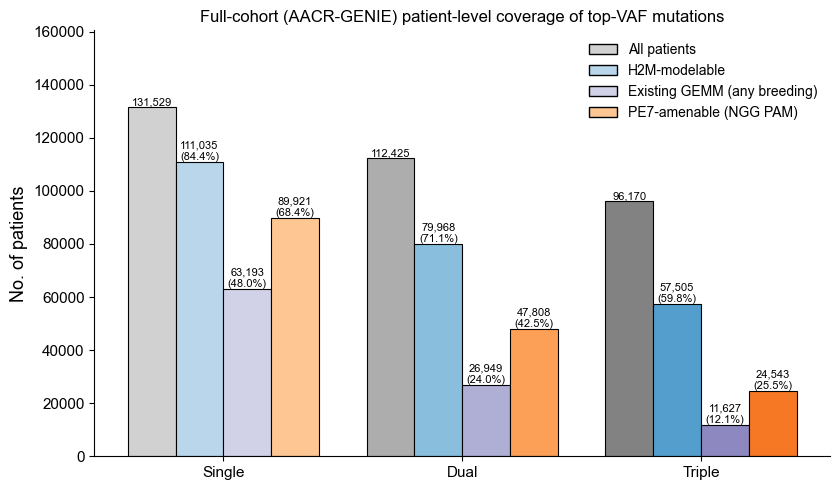

In [83]:
# --- Full-cohort patient-level coverage: All / H2M / GEMM / PE7-NGG ---
# Strict semantics: "Top-N covered" means top-1..N (by VAF rank) are ALL amenable.

def strict_topn_covered(df, flag_col):
    pv = df.pivot_table(index='Tumor_Sample_Barcode', columns='vaf_rank',
                        values=flag_col, aggfunc='first')
    out = {}
    for n in [1, 2, 3]:
        elig = pv.dropna(subset=list(range(1, n+1)))
        covered = elig[list(range(1, n+1))].all(axis=1)
        out[n] = (len(elig), int(covered.sum()))
    return out

h2m_res  = strict_topn_covered(df_top3_per_sample, 'h2m_modelable')
gemm_res = strict_topn_covered(df_top3_per_sample, 'gemm_amenable')
ngg_res  = strict_topn_covered(df_top3_per_sample, 'pe7_amenable_ngg')

results_full = {}
for n in [1, 2, 3]:
    n_total, n_h2m  = h2m_res[n]
    _,       n_gemm = gemm_res[n]
    _,       n_ngg  = ngg_res[n]
    results_full[n] = (n_total, n_h2m, n_gemm, n_ngg)
    print(f'Top-{n}: total {n_total:,} | H2M {n_h2m:,} ({n_h2m/n_total*100:.1f}%) '
          f'| GEMM {n_gemm:,} ({n_gemm/n_total*100:.1f}%) '
          f'| PE7-NGG {n_ngg:,} ({n_ngg/n_total*100:.1f}%)')

# --- 4-bar plot (full cohort: All / H2M / GEMM / PE7-NGG) ---
labels   = ['Single', 'Dual', 'Triple']
totals   = [results_full[n][0] for n in [1, 2, 3]]
h2m_cov  = [results_full[n][1] for n in [1, 2, 3]]
gemm_cov = [results_full[n][2] for n in [1, 2, 3]]
ngg_cov  = [results_full[n][3] for n in [1, 2, 3]]
h2m_pct  = [c/t*100 for c, t in zip(h2m_cov,  totals)]
gemm_pct = [c/t*100 for c, t in zip(gemm_cov, totals)]
ngg_pct  = [c/t*100 for c, t in zip(ngg_cov,  totals)]

grays_3   = sns.color_palette('Greys',   6)[1:4]
blues_3   = sns.color_palette('Blues',   6)[1:4]
purples_3 = sns.color_palette('Purples', 6)[1:4]
oranges_3 = sns.color_palette('Oranges', 6)[1:4]

fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(labels))
w = 0.20

for i in range(3):
    ax.bar(x[i] - 1.5*w, totals[i],   w, color=grays_3[i],   edgecolor='black', linewidth=0.8)
    ax.bar(x[i] - 0.5*w, h2m_cov[i],  w, color=blues_3[i],   edgecolor='black', linewidth=0.8)
    ax.bar(x[i] + 0.5*w, gemm_cov[i], w, color=purples_3[i], edgecolor='black', linewidth=0.8)
    ax.bar(x[i] + 1.5*w, ngg_cov[i],  w, color=oranges_3[i], edgecolor='black', linewidth=0.8)

for i in range(3):
    ax.text(x[i] - 1.5*w, totals[i],   f'{totals[i]:,}',
            ha='center', va='bottom', fontsize=8)
    ax.text(x[i] - 0.5*w, h2m_cov[i],  f'{h2m_cov[i]:,}\n({h2m_pct[i]:.1f}%)',
            ha='center', va='bottom', fontsize=8)
    ax.text(x[i] + 0.5*w, gemm_cov[i], f'{gemm_cov[i]:,}\n({gemm_pct[i]:.1f}%)',
            ha='center', va='bottom', fontsize=8)
    ax.text(x[i] + 1.5*w, ngg_cov[i],  f'{ngg_cov[i]:,}\n({ngg_pct[i]:.1f}%)',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylabel('No. of patients', fontsize=13)
ax.set_title('Full-cohort (AACR-GENIE) patient-level coverage of top-VAF mutations', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(totals) * 1.22)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=grays_3[0],   edgecolor='black', label='All patients'),
    Patch(facecolor=blues_3[0],   edgecolor='black', label='H2M-modelable'),
    Patch(facecolor=purples_3[0], edgecolor='black', label='Existing GEMM (any breeding)'),
    Patch(facecolor=oranges_3[0], edgecolor='black', label='PE7-amenable (NGG PAM)'),
]
ax.legend(handles=legend_elems, frameon=False, fontsize=10, loc='upper right')

fig.tight_layout()
plt.savefig('figures/full_patient_coverage.pdf', bbox_inches='tight')
plt.show()
